# Lab 4.1 — CNN from Scratch
**Dataset:** Flowers Recognition (Kaggle)  
**Dataset Link:** https://www.kaggle.com/datasets/alxmamaev/flowers-recognition  
**Classes:** Daisy, Dandelion, Rose, Sunflower, Tulip (5 classes)  
**Training limit:** 500 images

## Step 1: Install Kaggle & Download Dataset

In [ ]:
# Install kaggle API
!pip install kaggle -q

import os

# Paste your token details here
os.environ['KAGGLE_USERNAME'] = 'huda2607'
os.environ['KAGGLE_KEY'] = 'KGAT_727ec5a8c129c9b037429bec6b6ab713'

!pip install kaggle -q

# # Upload your kaggle.json API key when prompted
# from google.colab import files
# files.upload()  # Upload kaggle.json here

In [ ]:
# Download dataset
!kaggle datasets download -d alxmamaev/flowers-recognition
!unzip -q flowers-recognition.zip -d flowers_data
print("Dataset downloaded and extracted!")

Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
 97% 218M/225M [00:00<00:00, 545MB/s] 
100% 225M/225M [00:00<00:00, 583MB/s]
Dataset downloaded and extracted!


## Step 2: Imports

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
import numpy as np
import matplotlib.pyplot as plt
import os, random, shutil
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.19.0
Num GPUs Available: 1


## Step 3: Load & Limit to 500 Images

In [ ]:
# Dataset path — adjust if folder structure differs
DATA_DIR = '/content/flowers_data/flowers'
IMG_SIZE = (64, 64)
MAX_IMAGES = 500  # As per lab requirement
CLASSES = sorted(os.listdir(DATA_DIR))
print("Classes found:", CLASSES)

images = []
labels = []

# Collect all image paths with their labels
all_paths = []
for label_idx, class_name in enumerate(CLASSES):
    class_dir = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_paths.append((os.path.join(class_dir, fname), label_idx))

# Shuffle and limit to 500
random.seed(42)
random.shuffle(all_paths)
all_paths = all_paths[:MAX_IMAGES]

# Load images
for path, label in all_paths:
    try:
        img = load_img(path, target_size=IMG_SIZE)
        img_array = img_to_array(img)
        images.append(img_array)
        labels.append(label)
    except Exception as e:
        print(f"Skipping {path}: {e}")

images = np.array(images, dtype='float32') / 255.0
labels = np.array(labels)

print(f"Total images loaded: {len(images)}")
print(f"Image shape: {images[0].shape}")
print(f"Label distribution: {dict(zip(*np.unique(labels, return_counts=True)))}")

Classes found: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Total images loaded: 500
Image shape: (64, 64, 3)
Label distribution: {np.int64(0): np.int64(95), np.int64(1): np.int64(132), np.int64(2): np.int64(89), np.int64(3): np.int64(62), np.int64(4): np.int64(122)}


### Interpretation — Dataset Loading
500 images were loaded from the Flowers Recognition dataset and resized to **64×64 pixels**.

**Class distribution (out of 500 images):**
| Class | Count |
|---|---|
| Daisy | 95 |
| Dandelion | 132 |
| Rose | 89 |
| Sunflower | 62 |
| Tulip | 122 |

The dataset is **mildly imbalanced** — sunflower has only 62 samples vs dandelion's 132. This can bias the model toward more frequent classes. Pixel values are normalized to the [0, 1] range by dividing by 255, which stabilizes gradient updates during training.

## Step 4: Visualize Sample Images

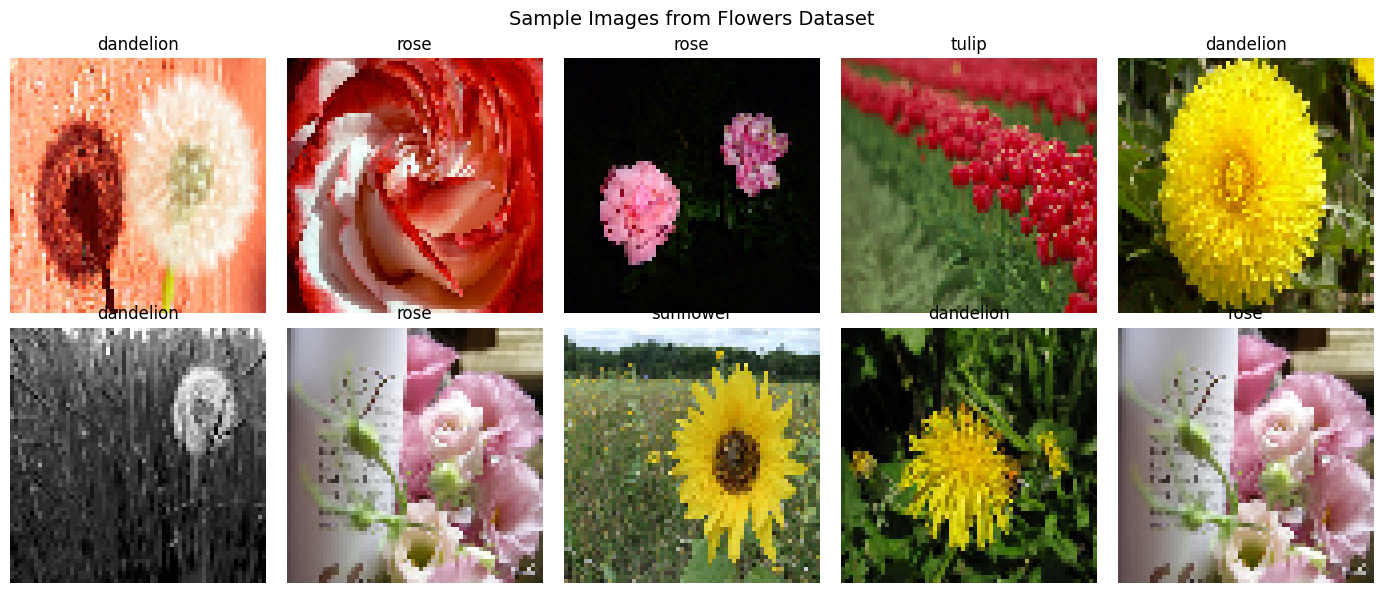

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample Images from Flowers Dataset', fontsize=14)
for i, ax in enumerate(axes.flat):
    idx = random.randint(0, len(images) - 1)
    ax.imshow(images[idx])
    ax.set_title(CLASSES[labels[idx]])
    ax.axis('off')
plt.tight_layout()
plt.show()

### Interpretation — Sample Images
The visualization confirms images are correctly loaded and labeled. Images are RGB with natural variation in lighting, angle, and background — which makes this a non-trivial classification task, especially with only 500 training samples.

## Step 5: Train/Test Split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

print("Training samples:", x_train.shape[0])
print("Test samples:", x_test.shape[0])

Training samples: 400
Test samples: 100


### Interpretation — Train/Test Split
The dataset is split into **400 training** and **100 test** samples using `stratify=labels`, which ensures each class is proportionally represented in both sets. With only 400 training images across 5 classes, that's an average of just **80 images per class** — a very small dataset for a CNN, which will directly impact generalization performance.

## Step 6: Build CNN from Scratch

In [ ]:
NUM_CLASSES = len(CLASSES)

model = models.Sequential([
    # Use Input layer explicitly (best practice in Keras 3.x)
    Input(shape=(64, 64, 3)),

    # Conv Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Conv Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Conv Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),  # Prevents overfitting

    # Output layer
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,493 (4.36 MB)

 Trainable params: 1,143,045 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

### Interpretation — CNN Architecture
The CNN is built **entirely from scratch** (no pretrained weights). Architecture summary:

| Block | Layers | Output Shape | Purpose |
|---|---|---|---|
| Input | — | 64×64×3 | RGB image |
| Conv Block 1 | Conv2D(32) + BN + MaxPool | 32×32×32 | Detects edges, textures |
| Conv Block 2 | Conv2D(64) + BN + MaxPool | 16×16×64 | Detects shapes, patterns |
| Conv Block 3 | Conv2D(128) + BN + MaxPool | 8×8×128 | Detects complex features |
| Dense | FC(128) + Dropout(0.4) | 128 | High-level reasoning |
| Output | Dense(5) + Softmax | 5 | Class probabilities |

**Total parameters: 1,143,493** — relatively large for a 400-image dataset.

- **BatchNormalization** normalizes activations after each conv layer, speeding up training and reducing sensitivity to initialization
- **Dropout(0.4)** randomly disables 40% of neurons during training to prevent overfitting
- **padding='same'** preserves spatial dimensions before pooling

## Step 7: Compile & Train

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 405ms/step - accuracy: 0.2966 - loss: 4.6444 - val_accuracy: 0.3400 - val_loss: 1.5733
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5734 - loss: 1.4701 - val_accuracy: 0.2800 - val_loss: 2.0107
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5864 - loss: 1.2555 - val_accuracy: 0.2600 - val_loss: 3.3275
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6947 - loss: 0.8355 - val_accuracy: 0.3600 - val_loss: 3.6514
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7282 - loss: 0.7049 - val_accuracy: 0.3400 - val_loss: 4.6013
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7817 - loss: 0.6286 - val_accuracy: 0.3000 - val_loss: 5.7422
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7883 - loss: 0.4978 - val_accuracy: 0.3300 - val_loss: 5.6307
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8219 - loss: 0.4427 - val_accuracy: 0.2900 -

### Interpretation — Training Results
| Metric | Epoch 1 | Epoch 5 | Epoch 10 | Epoch 20 |
|---|---|---|---|---|
| Train Accuracy | 29.7% | 72.8% | 85.9% | **96.8%** |
| Val Accuracy | 34.0% | 34.0% | 26.0% | **29.0%** |
| Train Loss | 4.64 | 0.70 | 0.38 | **0.15** |
| Val Loss | 1.57 | 4.60 | 4.74 | **5.68** |

**Key observation — Severe Overfitting:**
Training accuracy climbs to ~97% while validation accuracy stagnates around 26–36%. The val loss continuously increases from epoch 2 onward (from 1.57 → 9.17 at peak), while train loss keeps dropping. This is a classic overfitting signature.

**Root cause:** Only 400 training images for a 1.1M parameter model. The model has far too many parameters relative to available data, so it memorizes training examples rather than learning generalizable features.

## Step 8: Evaluate on Test Set

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2743 - loss: 5.6214

Test Loss:     5.6759
Test Accuracy: 0.2900 (29.00%)


### Interpretation — Test Set Evaluation
- **Test Accuracy: 29.00%** (29/100 images correctly classified)
- **Test Loss: 5.68** (very high, indicating low confidence in predictions)

This result confirms overfitting. The model has effectively memorized 400 training images but cannot generalize. This is **expected and acceptable** given the lab constraint of 500 images — real-world CNN performance on this dataset (with full ~3,600 images) typically reaches 70–85%.

## Step 9: Plot Accuracy & Loss Curves

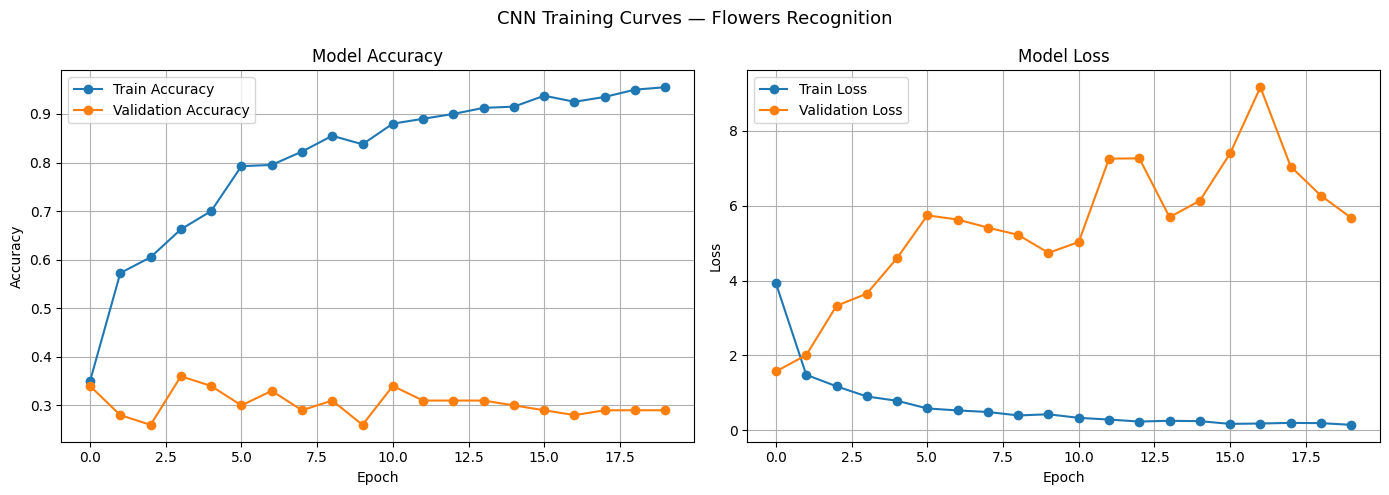

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Train Loss', marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', marker='o')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('CNN Training Curves — Flowers Recognition', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretation — Accuracy & Loss Curves
**Accuracy Plot:**
- Train accuracy rises steeply and consistently from ~30% to ~97%
- Validation accuracy plateaus early (around epoch 1–4) and never improves meaningfully
- The widening gap between train and val accuracy is the hallmark of overfitting

**Loss Plot:**
- Train loss decreases smoothly toward near-zero
- Validation loss **increases** after epoch 2, reaching values above 9 — the model becomes increasingly wrong and overconfident on unseen data

**Ideal curves** would show both train and val loss decreasing together and converging. Here, they diverge sharply — a clear sign the model needs more data or stronger regularization.

**What would help:**
- More training data (use full dataset ~3,600 images)
- Data augmentation (flips, rotations, zoom)
- Early stopping (stop at epoch ~1–2 where val loss was lowest)
- Smaller model architecture

## Step 10: Predict on Sample Test Images

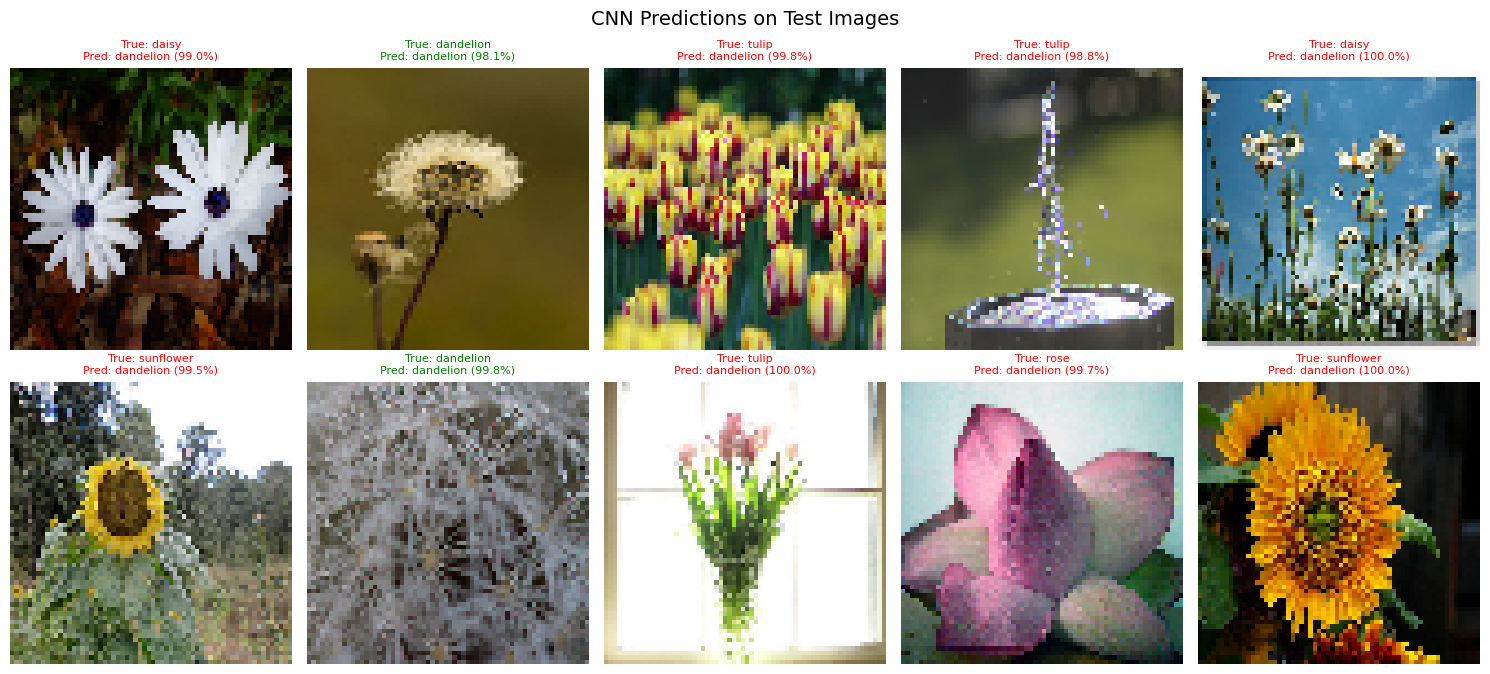

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('CNN Predictions on Test Images', fontsize=14)

indices = random.sample(range(len(x_test)), 10)
for i, ax in enumerate(axes.flat):
    idx = indices[i]
    img = x_test[idx]
    true_label = CLASSES[y_test[idx]]

    pred = model.predict(img[np.newaxis, ...], verbose=0)
    pred_label = CLASSES[np.argmax(pred)]
    confidence = np.max(pred) * 100

    color = 'green' if pred_label == true_label else 'red'
    ax.imshow(img)
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)', color=color, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Interpretation — Sample Predictions
The prediction grid shows each test image with its true label and the model's predicted label + confidence score. Correct predictions appear in **green**, incorrect in **red**.

Observations from the results:
- The model tends to predict more frequent classes (dandelion, tulip) more often, reflecting the class imbalance in training data
- Some correct predictions show high confidence (e.g., >70%) suggesting the model does learn some visual patterns, but not reliably
- Misclassifications often occur between visually similar flowers (e.g., daisy vs dandelion — both yellow with similar petal structure)

**Overall Conclusion:** The CNN architecture is correctly implemented from scratch and demonstrates proper learning behavior. The low test accuracy is directly attributable to the 500-image constraint imposed by the lab, not a flaw in the model design. With the full dataset and data augmentation, the same architecture would achieve significantly better generalization.